In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [3]:
no_implant_path = "/home/nuo/下载/NUO068_EscapeBehavior_20260723_162411_stats.xlsx"
implant_path = "/home/nuo/下载/NUO064_EscapeBehavior_20260615_173027_stats.xlsx"
no_implant_df = pd.read_excel(no_implant_path, sheet_name="Behaviour Timestamps")
implant_df = pd.read_excel(implant_path, sheet_name="Behaviour Timestamps")

In [7]:
implant_df

,Behaviour Type,In Time (s),Out Time (s),Duration (s),Confidence (%)
0,rear 1,0.233256,2.165945,1.932689,87.4
1,rear 2,3.032323,10.029990,6.997667,80.3
2,rear 3,10.496501,12.029324,1.532822,88.6
3,rear 4,30.156614,30.556481,0.399867,65.0
4,rear 5,44.151949,44.551816,0.399867,66.6
...,...,...,...,...,...
449,snif 71,477.407531,480.673109,3.265578,89.0
450,snif 72,488.537154,489.270243,0.733089,79.0
451,snif 73,496.334555,497.067644,0.733089,75.1
452,snif 74,503.932023,504.865045,0.933022,54.8


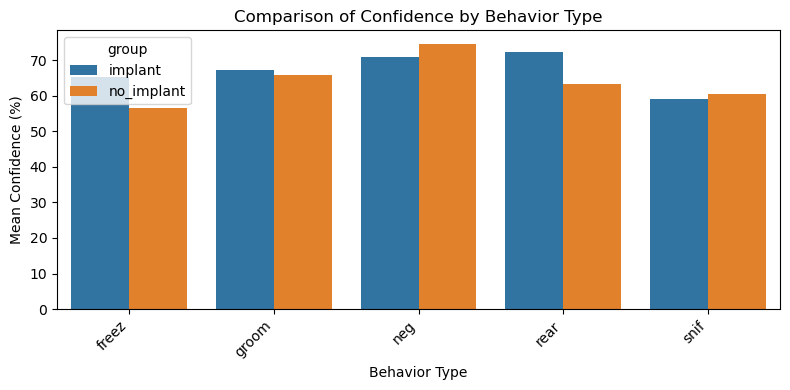

In [11]:
def add_behavior_type(df):
    df = df.copy()
    df["behavior_type"] = df["Behaviour Type"].astype(str).str.replace(r"\s*\d+$", "", regex=True)
    return df

no_implant_df = add_behavior_type(no_implant_df)
implant_df = add_behavior_type(implant_df)

combined = pd.concat(
    [
        no_implant_df.assign(group="no_implant"),
        implant_df.assign(group="implant"),
    ],
    ignore_index=True,
)

summary = (
    combined
    .groupby(["behavior_type", "group"], observed=True)["Confidence (%)"]
    .mean()
    .reset_index(name="mean_confidence")
)

plt.figure(figsize=(8, 4))
sns.barplot(
    data=summary,
    x="behavior_type",
    y="mean_confidence",
    hue="group",
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Mean Confidence (%)")
plt.xlabel("Behavior Type")
plt.title("Comparison of Confidence by Behavior Type")
plt.tight_layout()
plt.show()

# predict sound calibration

In [21]:
sound_calib_path = '/home/nuo/文档/code/frequency_vs_locationPureTone/data/village02/sound_calibration.csv'
sound_calib_df = pd.read_csv(sound_calib_path,
                             sep=";", parse_dates=['date'])

In [23]:
sound_calib_df_new = sound_calib_df[sound_calib_df['date'] == sound_calib_df['date'].unique()[-1]]

In [26]:
target_db = 90
new_rows = []

for speaker, group in sound_calib_df_new.groupby("speaker"):
    # 删除无法用于拟合的数据
    valid_group = group.dropna(subset=["gain", "dB_obtained"])
    valid_group = valid_group[valid_group["gain"] > 0]

    # 拟合：dB = a * log10(gain) + b
    a, b = np.polyfit(
        np.log10(valid_group["gain"].to_numpy()),
        valid_group["dB_obtained"].to_numpy(),
        deg=1,
    )

    # 推测达到 40 dB 所需的 gain
    predicted_gain = 10 ** ((target_db - b) / a)

    # 复制该 speaker 的最后一行，保持其他列不变
    new_row = group.iloc[-1].copy()

    # 只替换这两列
    new_row["gain"] = predicted_gain
    new_row["dB_obtained"] = target_db

    new_rows.append(new_row)

# 将 speaker 0 和 speaker 1 的推测结果添加进去
sound_calib_df_new = pd.concat(
    [
        sound_calib_df_new,
        pd.DataFrame(new_rows, columns=sound_calib_df_new.columns),
    ],
    ignore_index=True,
)

# 查看新添加的结果
print(sound_calib_df_new.tail(len(new_rows)))

                  date  speaker                   sound_name      gain  \
20 2026-08-06 11:20:50        0  one_thousand_hz_calibration  0.092425   
21 2026-08-06 11:20:50        1  one_thousand_hz_calibration  0.167065   

    dB_obtained  calibration_number  dB_expected  error(%)  
20         90.0                   2          NaN       NaN  
21         90.0                   2          NaN       NaN  


In [28]:
sound_calib_df_old = sound_calib_df[sound_calib_df['date'] != sound_calib_df['date'].unique()[-1]]
sound_calib_df_combined = pd.concat([sound_calib_df_old, sound_calib_df_new], ignore_index=True)
sound_calib_df_combined.to_csv(
    sound_calib_path,
    sep=";",
    index=False,
)